# SC2001 Project 1 — Integration of Merge Sort & Insertion Sort

## Hybrid Merge Sort Analysis

This notebook keeps the **same Hybrid Merge Sort implementation and experimental datasets / parameter values** as `hybrid_sort_analysis.py`.

Additional content:
- Reproducible random datasets using a fixed seed
- Median CPU-time measurements for C(ii) and C(iii)
- CPU-time measurements
- Original Merge Sort for Part (d)
- Part (d) uses **S = 8**
- Extra CPU-time graphs

The notebook does **not** automatically decide an optimal `S`; the suitable value/range can be inferred from the graphs.


## Imports

In [3]:
import random
import matplotlib.pyplot as plt
import math
import time
import gc
import statistics

# Fixed random seed so the same random datasets are generated
# every time the notebook is restarted and run from the top.
RANDOM_SEED = 2002
random.seed(RANDOM_SEED)

print(f"Random seed = {RANDOM_SEED}")

Random seed = 2002


### Reproducibility of the experiments

`random.seed(2002)` is used so that the same random datasets are generated every time the notebook is restarted and run from the beginning.

This does **not** change the sorting algorithm. It only makes the experiments reproducible.

For CPU-time experiments involving different `S` values, each timing is repeated several times and the **median CPU time** is used. This reduces the effect of small timing fluctuations caused by the operating system, memory allocation, caching, and other background activity.


# Part (a) — Algorithm Implementation

The following `generate_data`, `insertion_sort`, `hybrid_sort`, and `merge` functions are kept the same as the Python source file.


In [4]:
def generate_data(n, x):
    return [random.randint(1, x) for _ in range(n)]


def insertion_sort(A):

    n = len(A)
    comparisons = 0

    for i in range(1, n):

        j = i - 1

        while j >= 0:

            comparisons += 1

            if A[j] > A[j + 1]:
                A[j], A[j + 1] = A[j + 1], A[j]
                j -= 1
            else:
                break

    return A, comparisons


def hybrid_sort(A, S):

    if len(A) <= S:
        return insertion_sort(A)

    middle = len(A) // 2

    left = A[:middle]
    right = A[middle:]

    left, left_comparisons = hybrid_sort(left, S)
    right, right_comparisons = hybrid_sort(right, S)

    result, merge_comparisons = merge(left, right)

    total_comparisons = (
        left_comparisons
        + right_comparisons
        + merge_comparisons
    )

    return result, total_comparisons


def merge(left, right):

    result = []
    i = 0
    j = 0

    comparisons = 0

    while i < len(left) and j < len(right):

        comparisons += 1

        if left[i] <= right[j]:
            result.append(left[i])
            i += 1

        else:
            result.append(right[j])
            j += 1

    while i < len(left):
        result.append(left[i])
        i += 1

    while j < len(right):
        result.append(right[j])
        j += 1

    return result, comparisons

### Original Merge Sort for Part (d)

This uses the same `merge()` function and therefore counts key comparisons in the same way as the Hybrid Merge Sort.


In [5]:
def merge_sort(A):

    if len(A) <= 1:
        return A, 0

    middle = len(A) // 2

    left = A[:middle]
    right = A[middle:]

    left, left_comparisons = merge_sort(left)
    right, right_comparisons = merge_sort(right)

    result, merge_comparisons = merge(left, right)

    total_comparisons = (
        left_comparisons
        + right_comparisons
        + merge_comparisons
    )

    return result, total_comparisons

### Small correctness check

In [6]:
test_data = [8, 3, 2, 9, 1, 2, 0, 10, -2, 77]

hybrid_test, _ = hybrid_sort(test_data.copy(), 8)
merge_test, _ = merge_sort(test_data.copy())

print("Hybrid Sort correct:", hybrid_test == sorted(test_data))
print("Original Merge Sort correct:", merge_test == sorted(test_data))

Hybrid Sort correct: True
Original Merge Sort correct: True


# Part (c)(i) — Fixed S = 15, Varying Input Size

The input sizes and `S = 15` are exactly the same as the Python source file.

CPU time is added as an extra measurement, but the key-comparison experiment is unchanged.


In [5]:
x = 10000000
S = 15

size = [
    1000,
    3000,
    5000,
    7000,
    10000,
    30000,
    50000,
    70000,
    100000,
    300000,
    500000,
    700000,
    1000000,
    3000000,
    5000000,
    7000000,
    10000000
]

results = []
time_results_ci = []

for n in size:
    data = generate_data(n, x)

    start_time = time.process_time()
    sorted_data, comparisons = hybrid_sort(data, S)
    cpu_time = time.process_time() - start_time

    results.append((n, comparisons))
    time_results_ci.append((n, cpu_time))

    print(
        f"n = {n:,}, "
        f"key comparisons = {comparisons:,}, "
        f"CPU time = {cpu_time:.5f}s"
    )

    del data, sorted_data
    gc.collect()

n = 1,000, key comparisons = 9,558, CPU time = 0.00000s
n = 3,000, key comparisons = 33,801, CPU time = 0.00000s
n = 5,000, key comparisons = 58,411, CPU time = 0.01562s
n = 7,000, key comparisons = 89,596, CPU time = 0.01562s
n = 10,000, key comparisons = 127,051, CPU time = 0.01562s
n = 30,000, key comparisons = 452,134, CPU time = 0.06250s
n = 50,000, key comparisons = 769,567, CPU time = 0.06250s
n = 70,000, key comparisons = 1,073,838, CPU time = 0.10938s
n = 100,000, key comparisons = 1,639,015, CPU time = 0.15625s
n = 300,000, key comparisons = 5,258,664, CPU time = 0.54688s
n = 500,000, key comparisons = 9,440,212, CPU time = 0.98438s
n = 700,000, key comparisons = 13,279,955, CPU time = 1.40625s
n = 1,000,000, key comparisons = 19,890,178, CPU time = 2.21875s
n = 3,000,000, key comparisons = 63,546,256, CPU time = 7.34375s
n = 5,000,000, key comparisons = 108,215,306, CPU time = 12.73438s
n = 7,000,000, key comparisons = 158,966,967, CPU time = 18.84375s
n = 10,000,000, key co

### Graph 1 — Number of Key Comparisons vs Input Size

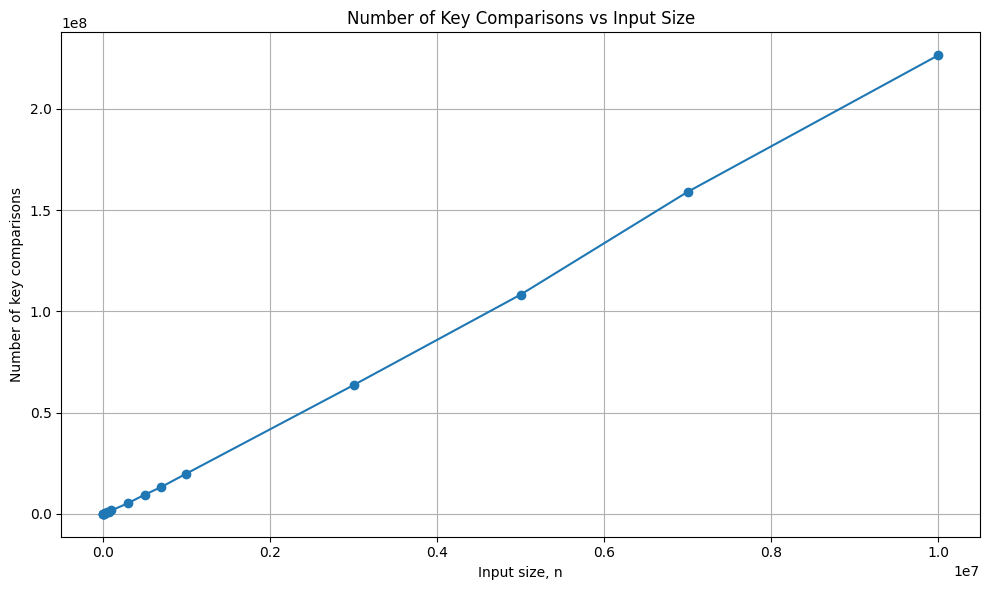

In [6]:
array = [result[0] for result in results]
comparison = [result[1] for result in results]

plt.figure(figsize=(10, 6))

plt.plot(
    array,
    comparison,
    marker='o'
)

plt.xlabel("Input size, n")
plt.ylabel("Number of key comparisons")
plt.title("Number of Key Comparisons vs Input Size")

plt.grid(True)
plt.tight_layout()

plt.show()

### Graph 2 — Empirical Results vs Theoretical O(n log n)

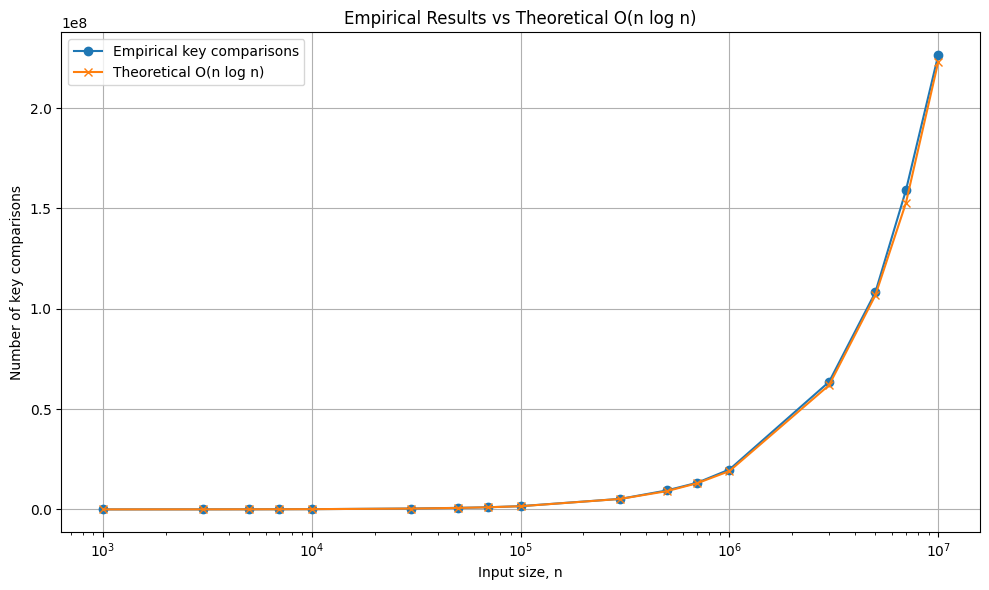

In [7]:
theoretical_values = [
    n * math.log2(n)
    for n in array
]

# Scale theoretical curve to make it comparable
scale = comparison[0] / theoretical_values[0]

scaled_theoretical = [
    value * scale
    for value in theoretical_values
]

plt.figure(figsize=(10, 6))

plt.plot(
    array,
    comparison,
    marker='o',
    label="Empirical key comparisons"
)

plt.plot(
    array,
    scaled_theoretical,
    marker='x',
    label="Theoretical O(n log n)"
)

plt.xscale("log")

plt.xlabel("Input size, n")
plt.ylabel("Number of key comparisons")
plt.title("Empirical Results vs Theoretical O(n log n)")

plt.legend()
plt.grid(True)
plt.tight_layout()

plt.show()

### Graph 3 — CPU Time vs Input Size

This is an additional time measurement. Dataset generation is outside the timer.


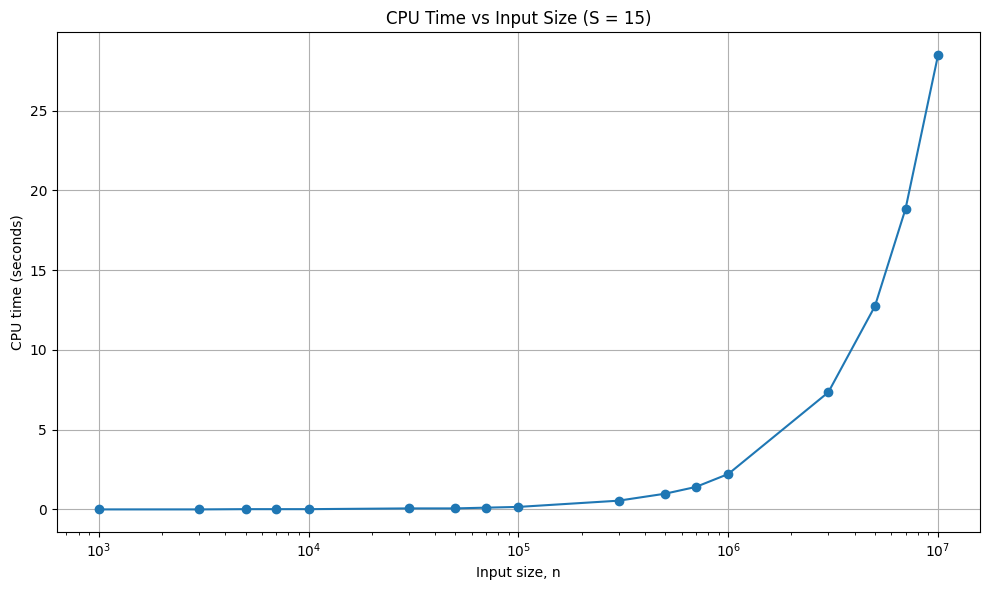

In [8]:
cpu_time_ci = [result[1] for result in time_results_ci]

plt.figure(figsize=(10, 6))

plt.plot(
    array,
    cpu_time_ci,
    marker='o'
)

plt.xscale("log")

plt.xlabel("Input size, n")
plt.ylabel("CPU time (seconds)")
plt.title("CPU Time vs Input Size (S = 15)")

plt.grid(True)
plt.tight_layout()

plt.show()

### C(i) Complexity

With `S` fixed, the use of Insertion Sort on small subarrays does not change the overall asymptotic complexity.

\[
T(n) = O(n \log n)
\]

The empirical comparison graph is therefore compared with the theoretical `n log n` growth trend.


# Part (c)(ii) — Fixed n = 100,000, Varying S

The fixed input size and `S` values below are exactly the same as the Python source file:

`[1, 2, 3, 4, 5, 10, 20, 40, 50, 100, 200, 500]`

The same generated dataset is copied for every `S`, exactly as in the original experiment.


In [9]:
# Fixed input size n = 100,000
n = 100000

# Generate a list of values for S to be tested
S_values = [1, 2, 3, 4, 5, 10, 20, 40, 50, 100, 200, 500]

# Repeat the CPU-time measurement for each S value.
CII_REPEATS = 5

# Generate one fixed dataset so every S uses the same data
data = generate_data(n, x)

results_cii = []
time_results_cii = []

for S in S_values:

    time_list = []
    comparisons = None

    for repeat in range(CII_REPEATS):

        # Create a copy of the same original data for every run
        testing_data = data.copy()

        start_time = time.process_time()
        sorted_data, run_comparisons = hybrid_sort(testing_data, S)
        cpu_time = time.process_time() - start_time

        time_list.append(cpu_time)

        # The key-comparison count is deterministic for the same
        # dataset and S, so it only needs to be stored once.
        if comparisons is None:
            comparisons = run_comparisons

        del testing_data, sorted_data

    median_cpu_time = statistics.median(time_list)

    results_cii.append((S, comparisons))
    time_results_cii.append((S, median_cpu_time))

    print(
        f"S = {S}, "
        f"key comparisons = {comparisons:,}, "
        f"median CPU time = {median_cpu_time:.5f}s"
    )

del data
gc.collect()

S = 1, key comparisons = 1,536,438, median CPU time = 0.20312s
S = 2, key comparisons = 1,536,438, median CPU time = 0.17188s
S = 3, key comparisons = 1,536,512, median CPU time = 0.15625s
S = 4, key comparisons = 1,536,896, median CPU time = 0.15625s
S = 5, key comparisons = 1,536,896, median CPU time = 0.15625s
S = 10, key comparisons = 1,557,939, median CPU time = 0.15625s
S = 20, key comparisons = 1,639,237, median CPU time = 0.15625s
S = 40, key comparisons = 1,862,582, median CPU time = 0.17188s
S = 50, key comparisons = 2,379,128, median CPU time = 0.20312s
S = 100, key comparisons = 3,500,958, median CPU time = 0.29688s
S = 200, key comparisons = 5,857,127, median CPU time = 0.46875s
S = 500, key comparisons = 10,629,386, median CPU time = 0.84375s


23689

### Graph 4 — Number of Key Comparisons vs S Value

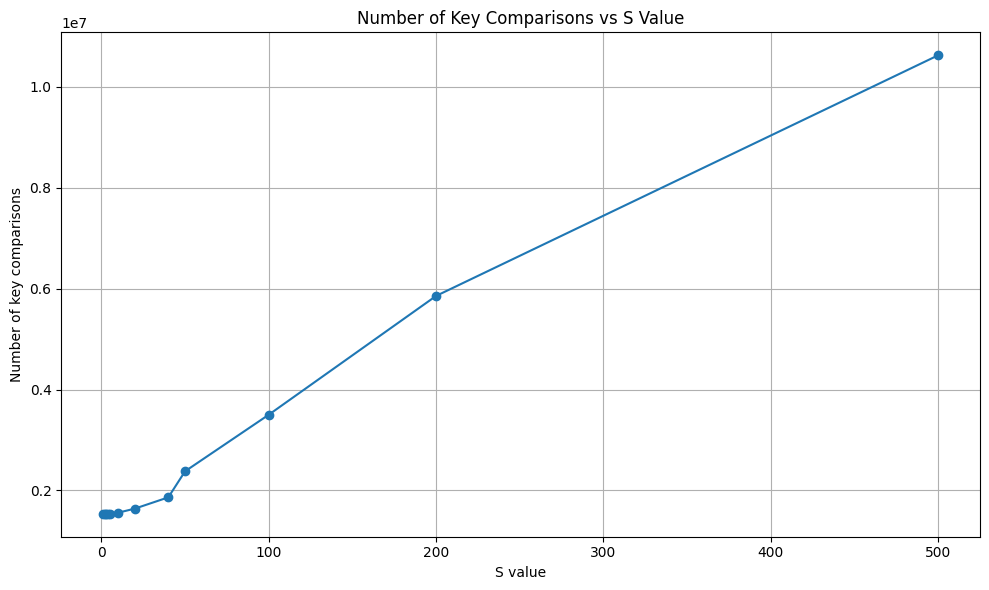

In [10]:
S_values_array = [result[0] for result in results_cii]
comparison_s_array = [result[1] for result in results_cii]

plt.figure(figsize=(10, 6))

plt.plot(
    S_values_array,
    comparison_s_array,
    marker='o'
)

plt.xlabel("S value")
plt.ylabel("Number of key comparisons")
plt.title("Number of Key Comparisons vs S Value")

plt.grid(True)
plt.tight_layout()

plt.show()

### C(ii) — Empirical Results vs Theoretical Analysis

For C(ii), the input size `n` is fixed while the threshold `S` changes.

The hybrid algorithm has two main sources of work:

\[
T(n,S)
=
O\left(n\log\frac{n}{S}\right)
+
O(nS)
\]

- **Merge Sort part:** \(O(n\log(n/S))\)  
  As `S` increases, fewer merge levels are needed.

- **Insertion Sort part:** \(O(nS)\)  
  There are approximately \(n/S\) small subarrays, and sorting each subarray of size about `S` takes \(O(S^2)\), giving \(O(nS)\) overall.

Therefore, when `S` is small, the Merge Sort component dominates. As `S` becomes large, the Insertion Sort component becomes increasingly significant. This predicts that the number of comparisons should remain relatively low for small `S` values and then increase as `S` becomes large, which is the trend observed in the empirical results.

The theoretical curve below is **scaled only for visual comparison of the growth trend**. It is not intended to predict the exact number of comparisons.


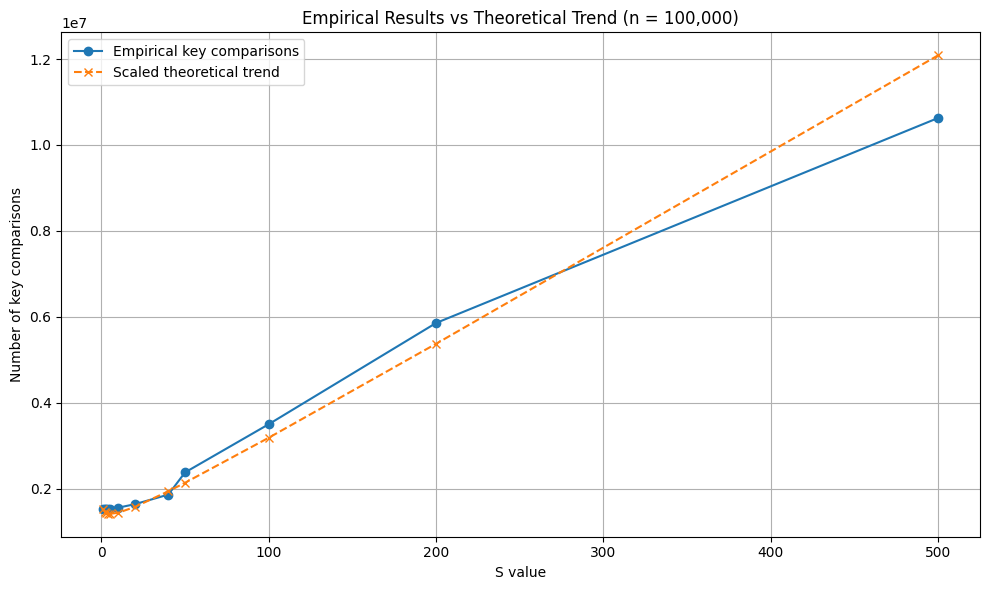

In [11]:
# Theoretical trend for C(ii):
# O(n log(n/S)) for the merge levels
# + O(nS) for insertion sorting the small subarrays.
#
# For random data, the average insertion-sort comparison count is
# approximately proportional to S^2 / 4 per subarray, so n*S/4 is
# used here as a theoretical comparison proxy.

theoretical_cii = []

for S_value in S_values_array:

    merge_component = (
        n * math.log2(n / S_value)
        if S_value < n
        else 0
    )

    insertion_component = n * S_value / 4

    theoretical_cii.append(
        merge_component + insertion_component
    )

# Scale the theoretical curve to the empirical data so that
# the shapes can be compared on the same graph.
theoretical_scale_cii = (
    comparison_s_array[0]
    / theoretical_cii[0]
)

scaled_theoretical_cii = [
    value * theoretical_scale_cii
    for value in theoretical_cii
]

plt.figure(figsize=(10, 6))

plt.plot(
    S_values_array,
    comparison_s_array,
    marker='o',
    label="Empirical key comparisons"
)

plt.plot(
    S_values_array,
    scaled_theoretical_cii,
    marker='x',
    linestyle='--',
    label="Scaled theoretical trend"
)

plt.xlabel("S value")
plt.ylabel("Number of key comparisons")
plt.title(
    "Empirical Results vs Theoretical Trend "
    "(n = 100,000)"
)

plt.legend()
plt.grid(True)
plt.tight_layout()

plt.show()

### C(ii) Comparison

The empirical results are consistent with the theoretical analysis:

- At small `S`, changing the threshold has only a limited effect on the total number of comparisons because Merge Sort still performs most of the work.
- As `S` becomes larger, more work is transferred to Insertion Sort.
- Since Insertion Sort has quadratic complexity on a subarray, using a very large `S` causes the total number of key comparisons to rise significantly.

Hence, the experiment supports the theoretical trade-off described by

\[
O\left(n\log\frac{n}{S} + nS\right).
\]

This also explains why a moderate threshold is preferable to an excessively large one.


### Graph 5 — Median CPU Time vs S Value

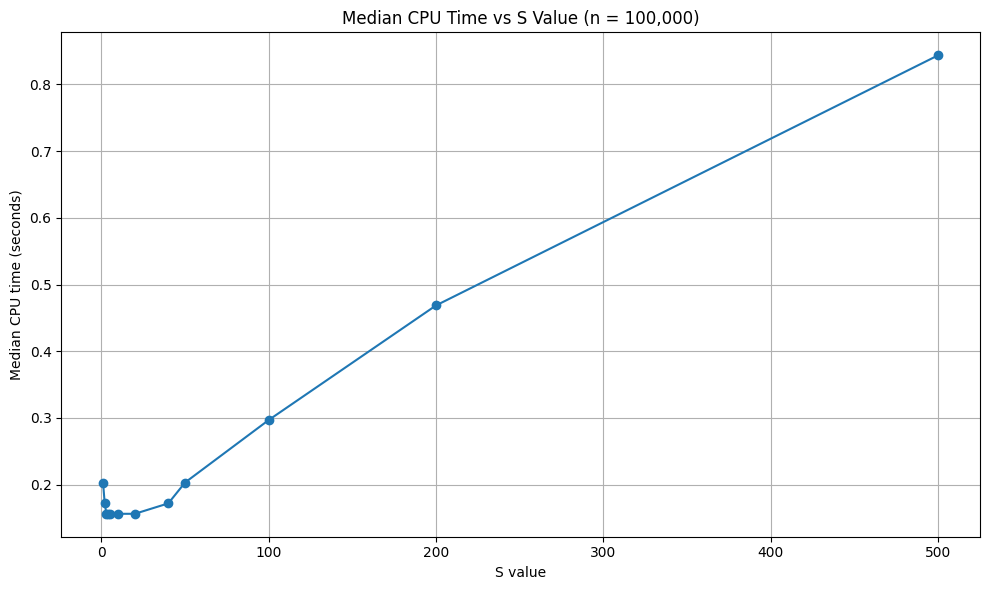

In [12]:
cpu_time_s_array = [result[1] for result in time_results_cii]

plt.figure(figsize=(10, 6))

plt.plot(
    S_values_array,
    cpu_time_s_array,
    marker='o'
)

plt.xlabel("S value")
plt.ylabel("Median CPU time (seconds)")
plt.title("Median CPU Time vs S Value (n = 100,000)")

plt.grid(True)
plt.tight_layout()

plt.show()

# Part (c)(iii) — Different Input Sizes

The input sizes and candidate `S` values are exactly the same as the Python source file.

No optimal `S` is automatically selected in this notebook. Infer a suitable value/range from the graphs.


In [13]:
n_values_ciii = [
    10000,
    100000,
    1000000
]

S_values_ciii = [
    1, 2, 3, 4, 5,
    6, 7, 8, 9, 10,
    12, 15, 20, 25, 30
]

# Repeat CPU timing for each (n, S) pair and use the median.
CIII_REPEATS = 3

results_ciii = []
time_results_ciii = []

for n_test in n_values_ciii:

    print()
    print(f"Testing n = {n_test:,}")

    # One fixed dataset is generated for this input size.
    # Every S value is tested using copies of this same dataset.
    data = generate_data(n_test, x)

    for S_test in S_values_ciii:

        time_list = []
        comparisons = None

        for repeat in range(CIII_REPEATS):

            testing_data = data.copy()

            start_time = time.process_time()
            sorted_data, run_comparisons = hybrid_sort(
                testing_data,
                S_test
            )
            cpu_time = time.process_time() - start_time

            time_list.append(cpu_time)

            # Key comparisons are deterministic for the same
            # dataset and S, so store them only once.
            if comparisons is None:
                comparisons = run_comparisons

            del testing_data, sorted_data

        median_cpu_time = statistics.median(time_list)

        results_ciii.append(
            (
                n_test,
                S_test,
                comparisons
            )
        )

        time_results_ciii.append(
            (
                n_test,
                S_test,
                median_cpu_time
            )
        )

        print(
            f"n = {n_test:,}, "
            f"S = {S_test}, "
            f"comparisons = {comparisons:,}, "
            f"median CPU time = {median_cpu_time:.5f}s"
        )

    del data
    gc.collect()


Testing n = 10,000
n = 10,000, S = 1, comparisons = 120,493, median CPU time = 0.01562s
n = 10,000, S = 2, comparisons = 120,493, median CPU time = 0.01562s
n = 10,000, S = 3, comparisons = 120,493, median CPU time = 0.01562s
n = 10,000, S = 4, comparisons = 120,577, median CPU time = 0.01562s
n = 10,000, S = 5, comparisons = 121,688, median CPU time = 0.01562s
n = 10,000, S = 6, comparisons = 121,688, median CPU time = 0.01562s
n = 10,000, S = 7, comparisons = 121,688, median CPU time = 0.01562s
n = 10,000, S = 8, comparisons = 121,688, median CPU time = 0.01562s
n = 10,000, S = 9, comparisons = 122,698, median CPU time = 0.01562s
n = 10,000, S = 10, comparisons = 126,986, median CPU time = 0.01562s
n = 10,000, S = 12, comparisons = 126,986, median CPU time = 0.00000s
n = 10,000, S = 15, comparisons = 126,986, median CPU time = 0.01562s
n = 10,000, S = 20, comparisons = 143,921, median CPU time = 0.01562s
n = 10,000, S = 25, comparisons = 143,921, median CPU time = 0.01562s
n = 10,00

### Graph 6 — Number of Key Comparisons vs S for Different Input Sizes

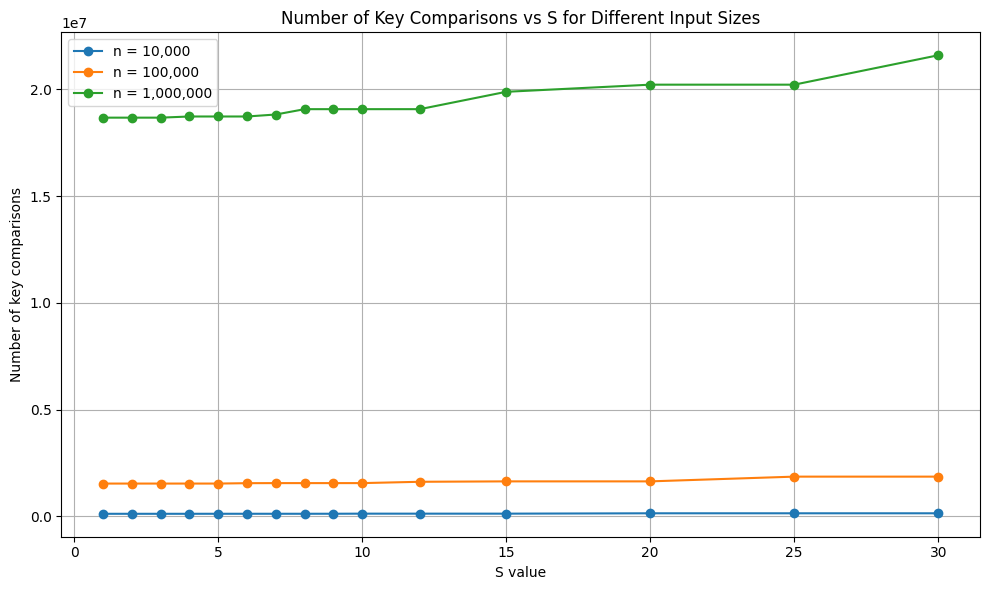

In [14]:
plt.figure(figsize=(10, 6))

for n_test in n_values_ciii:

    S_for_n = []
    comparisons_for_n = []

    for result in results_ciii:

        if result[0] == n_test:

            S_for_n.append(result[1])
            comparisons_for_n.append(result[2])

    plt.plot(
        S_for_n,
        comparisons_for_n,
        marker='o',
        label=f"n = {n_test:,}"
    )

plt.xlabel("S value")
plt.ylabel("Number of key comparisons")
plt.title(
    "Number of Key Comparisons vs S "
    "for Different Input Sizes"
)

plt.legend()
plt.grid(True)
plt.tight_layout()

plt.show()

### Graph 7 — Median CPU Time vs S for Different Input Sizes

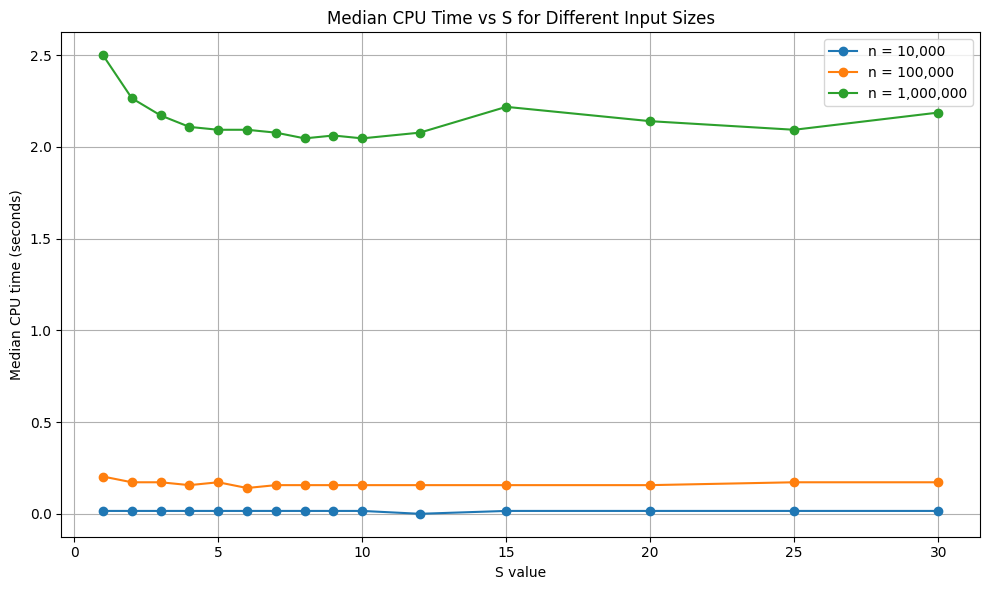

In [15]:
plt.figure(figsize=(10, 6))

for n_test in n_values_ciii:

    S_for_n = []
    cpu_for_n = []

    for result in time_results_ciii:

        if result[0] == n_test:

            S_for_n.append(result[1])
            cpu_for_n.append(result[2])

    plt.plot(
        S_for_n,
        cpu_for_n,
        marker='o',
        label=f"n = {n_test:,}"
    )

plt.xlabel("S value")
plt.ylabel("Median CPU time (seconds)")
plt.title(
    "Median CPU Time vs S "
    "for Different Input Sizes"
)

plt.legend()
plt.grid(True)
plt.tight_layout()

plt.show()

### C(iii) Interpretation

Use the key-comparison and CPU-time graphs together to infer a suitable threshold.

For Part (d), the chosen threshold is fixed at:

**S = 8**


### Note on Part (d) timing

For C(ii) and C(iii), repeated timings are practical because the datasets are smaller.

Part (d) uses **10,000,000 integers**, so the final Original Merge Sort and Hybrid Merge Sort runs are each timed once to avoid multiplying the already heavy runtime and memory workload. Both algorithms still use the **same generated dataset**, so the comparison remains fair.


# Part (d) — Original Merge Sort vs Hybrid Merge Sort

Dataset size: **10,000,000 integers**

Hybrid Merge Sort threshold: **S = 8**

Both algorithms are run on the same generated dataset and compared using:
- number of key comparisons
- CPU time


In [16]:
n_final = 10_000_000
S_PART_D = 8

print(f"Generating dataset with {n_final:,} integers...")
final_data = generate_data(n_final, x)
print("Dataset generated.")

Generating dataset with 10,000,000 integers...
Dataset generated.


### Run Original Merge Sort

In [17]:
start_time = time.process_time()

merge_sorted, merge_comparisons = merge_sort(final_data)

merge_cpu_time = time.process_time() - start_time

print("Original Merge Sort")
print(f"Key comparisons = {merge_comparisons:,}")
print(f"CPU time = {merge_cpu_time:.5f}s")

del merge_sorted
gc.collect()

Original Merge Sort
Key comparisons = 220,101,365
CPU time = 32.84375s


7281

### Run Hybrid Merge Sort with S = 8

In [18]:
start_time = time.process_time()

hybrid_sorted, hybrid_comparisons = hybrid_sort(
    final_data,
    S_PART_D
)

hybrid_cpu_time = time.process_time() - start_time

print(f"Hybrid Merge Sort (S = {S_PART_D})")
print(f"Key comparisons = {hybrid_comparisons:,}")
print(f"CPU time = {hybrid_cpu_time:.5f}s")

del hybrid_sorted
gc.collect()

Hybrid Merge Sort (S = 8)
Key comparisons = 221,109,507
CPU time = 29.00000s


0

### Graph 8 — Final Performance Comparison

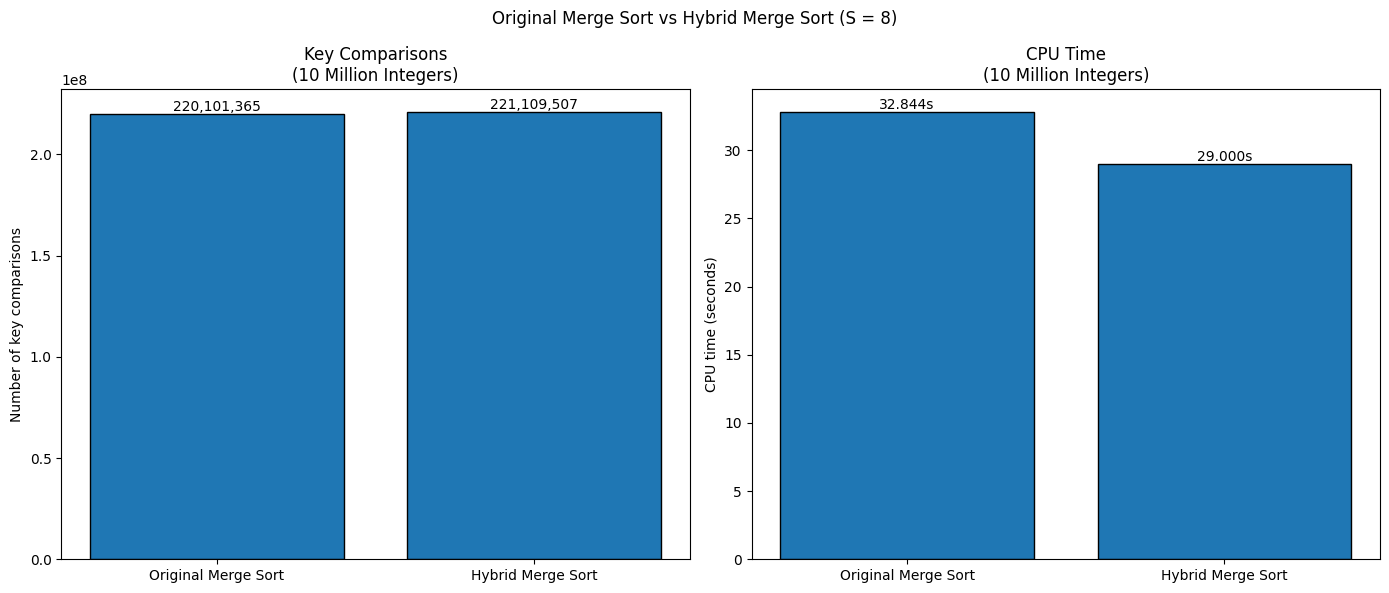

In [19]:
algorithms = [
    "Original Merge Sort",
    "Hybrid Merge Sort"
]

comparisons_d = [
    merge_comparisons,
    hybrid_comparisons
]

cpu_times_d = [
    merge_cpu_time,
    hybrid_cpu_time
]

fig, (ax1, ax2) = plt.subplots(
    1,
    2,
    figsize=(14, 6)
)

# Key comparisons
bars1 = ax1.bar(
    algorithms,
    comparisons_d,
    edgecolor='black'
)

ax1.set_title("Key Comparisons\n(10 Million Integers)")
ax1.set_ylabel("Number of key comparisons")

for bar, value in zip(bars1, comparisons_d):
    ax1.text(
        bar.get_x() + bar.get_width() / 2,
        bar.get_height(),
        f"{value:,}",
        ha="center",
        va="bottom"
    )

# CPU time
bars2 = ax2.bar(
    algorithms,
    cpu_times_d,
    edgecolor='black'
)

ax2.set_title("CPU Time\n(10 Million Integers)")
ax2.set_ylabel("CPU time (seconds)")

for bar, value in zip(bars2, cpu_times_d):
    ax2.text(
        bar.get_x() + bar.get_width() / 2,
        bar.get_height(),
        f"{value:.3f}s",
        ha="center",
        va="bottom"
    )

plt.suptitle("Original Merge Sort vs Hybrid Merge Sort (S = 8)")
plt.tight_layout()
plt.show()

In [20]:
print("=" * 60)
print("PART (d) PERFORMANCE COMPARISON")
print("=" * 60)
print(f"Dataset size: {n_final:,}")
print(f"Hybrid S: {S_PART_D}")
print()
print(f"{'Algorithm':<28}{'Comparisons':>16}{'CPU time (s)':>16}")
print("-" * 60)
print(
    f"{'Original Merge Sort':<28}"
    f"{merge_comparisons:>16,}"
    f"{merge_cpu_time:>16.5f}"
)
print(
    f"{'Hybrid Merge Sort':<28}"
    f"{hybrid_comparisons:>16,}"
    f"{hybrid_cpu_time:>16.5f}"
)
print("=" * 60)

PART (d) PERFORMANCE COMPARISON
Dataset size: 10,000,000
Hybrid S: 8

Algorithm                        Comparisons    CPU time (s)
------------------------------------------------------------
Original Merge Sort              220,101,365        32.84375
Hybrid Merge Sort                221,109,507        29.00000


### Interpretation of Part (d)

The hybrid algorithm with \(S = 8\) performed **221,109,507 key comparisons**, compared with **220,101,365** for the original Merge Sort. This is approximately **0.46% more key comparisons**.

However, the hybrid algorithm required only **29.00 s of CPU time**, compared with **32.84 s** for the original Merge Sort, giving an observed CPU-time reduction of approximately **11.7%**.

This shows that **fewer key comparisons do not necessarily mean faster execution**. Key comparisons measure only one part of the total computational cost. The hybrid algorithm stops the Merge Sort recursion earlier, reducing recursive calls, list slicing, and merge operations. In this experiment, these savings outweighed the small increase in comparisons introduced by Insertion Sort.

Therefore, \(S = 8\) is treated as a **practical threshold for this implementation and execution environment**, rather than a universally optimal value.

# Presentation Order

1. Hybrid Sort implementation
2. C(i): comparisons vs input size
3. C(i): empirical vs theoretical O(n log n)
4. C(i): CPU time vs input size
5. C(ii): comparisons vs S
6. C(ii): empirical vs theoretical trend
7. C(ii): CPU time vs S
8. C(iii): comparisons vs S for different input sizes
9. C(iii): CPU time vs S for different input sizes
10. Part (d): Original Merge Sort vs Hybrid Merge Sort using S = 8
